In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USE YOUR GROUP NUMBER AS THE SEED
SEED = 2  # TO DO: set your group seed (keep it fixed for reproducibility)
np.random.seed(SEED)

## 1. Load and Inspect the Dataset

Required file: `Diabetes.csv`

TO DO:
1) Load the CSV into a DataFrame named `df`  
2) Display the first 5 rows  
3) Report: number of rows, number of columns  
4) Check data types  


In [3]:
# TO DO: load dataset (hint: pd.read_csv)
df = pd.read_csv('Diabetes.csv')

# Preview first 5 rows
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# TO DO: show dataset shape (rows, columns)
print(f"數據集包含 {df.shape[0]} 行 (rows) 和 {df.shape[1]} 列 (columns)")


數據集包含 768 行 (rows) 和 9 列 (columns)


In [5]:
# TO DO: inspect data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Interpretation (3–5 lines):
- How many observations and variables?
- What is the outcome variable?
- What types of variables do you see (continuous vs discrete/binary)?

In [ ]:
-The dataset contains 768 observations and 9 variables.
-The outcome variable is Outcome, which indicates whether a person has diabetes (1) or not (0).
-continuous:Glucose、BloodPressure、SkinThickness、Insulin、BMI、DiabetesPedigreeFunction                   
discrete:Pregnancies、Age  
binary:Outcome

## 2. Data Quality Checks

TO DO:
1) Summary statistics (`describe`)  
2) Missing value check  
3) Identify suspicious values (e.g., zeros where impossible/unlikely)  


In [6]:
# TO DO: summary statistics (hint: df.describe())
summary = df.describe()
summary


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
# TO DO: missing values count (hint: df.isna().sum())
missing_counts = df.isna().sum()
missing_counts

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
# TO DO (optional): count how many zeros appear in selected variables
vars_to_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 統計這些欄位中數值等於 0 的數量
zero_counts = (df[vars_to_check] == 0).sum()
zero_counts


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Interpretation (5–8 lines):
- Are there missing values?
- Which variables have suspicious values?
- What might those suspicious values mean for analysis (e.g., missing coded as 0)?

In [ ]:
-There are no officially recorded missing values in the dataset. 
However, several variables contain suspicious zero values that likely represent hidden missing data.
-Glucose, BloodPressure, SkinThickness, Insulin, and BMI contain suspicious zero values.
These zeros are physiologically impossible and should be considered missing values.
-These zeros may represent missing data coded as 0, which could affect the accuracy of the analysis.

## 3. Required Visualizations (Matplotlib Default)

You must produce the following plots using **matplotlib**:

A) Histogram of Glucose  
B) Histogram of BMI  
C) Boxplot of Glucose by Outcome  
D) Scatter: Age vs BMI (use color/marker by Outcome)

After each plot, write a short interpretation (2–4 lines).


### 3A. Histogram of Glucose

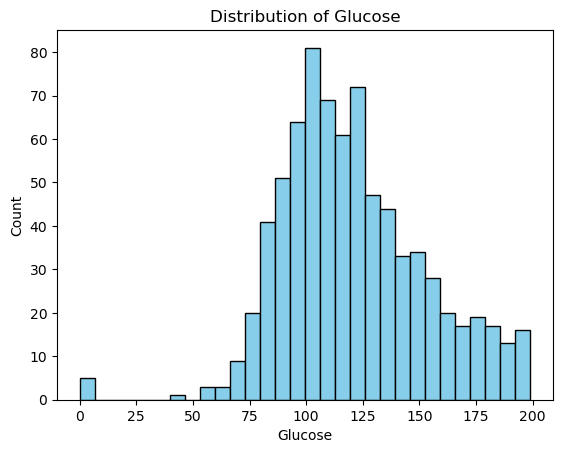

In [9]:
plt.figure()

# TO DO: histogram of Glucose (hint: plt.hist)
# Use 30 bins.
plt.hist(df['Glucose'], bins=30, color='skyblue', edgecolor='black')

plt.title("Distribution of Glucose")
plt.xlabel("Glucose")
plt.ylabel("Count")
plt.show()

Interpretation: Describe shape, center, spread, and any unusual features/outliers.

In [ ]:
shap:Unimodal and clearly right-skewed
center:The peak (mode) of the data falls roughly between 100 and 110.
The overall range of the data extends from 0 to 200. 
The main observations are concentrated between 75 and 150.
Unusual Features/Outliers:A small, noticeable bar appears at the position of 0. 
In medical data, a blood glucose value of 0 is highly unusual, typically indicating missing values or input errors in the dataset.

### 3B. Histogram of BMI

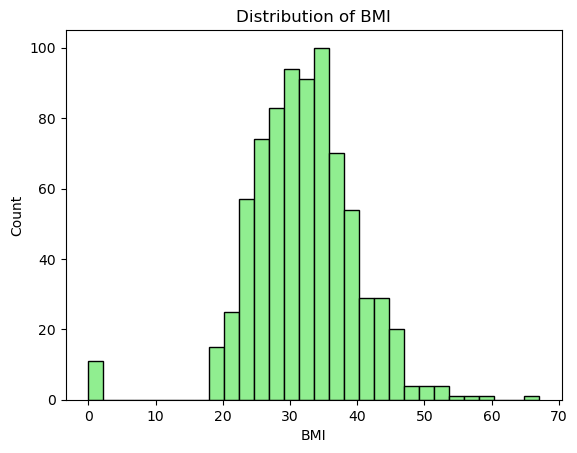

In [10]:
plt.figure()

# TO DO: histogram of BMI (hint: plt.hist)
# Use 30 bins.
plt.hist(df['BMI'], bins=30, color='lightgreen', edgecolor='black')

plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

Interpretation: Describe shape, center, spread, and any unusual features/outliers.

In [ ]:
shap:Unimodal and right-skewed
center:The median is roughly between 30 and 35. 
Due to the right skewness of the data, the mean may be slightly higher than the median.
spread:The data is widely distributed. 
Most values are between 20 and 50, but the overall range extends from close to 0 to nearly 70.
Unusual Features/Outliers:
Low-end outliers: A small, isolated bar near a BMI of 0 is unusual and most likely indicates a data entry error or a missing value.
High-end outliers: Scattered data points above a BMI of 60, while statistically possible in cases of extreme obesity, stand out significantly compared to the main population.

### 3C. Boxplot: Glucose by Outcome

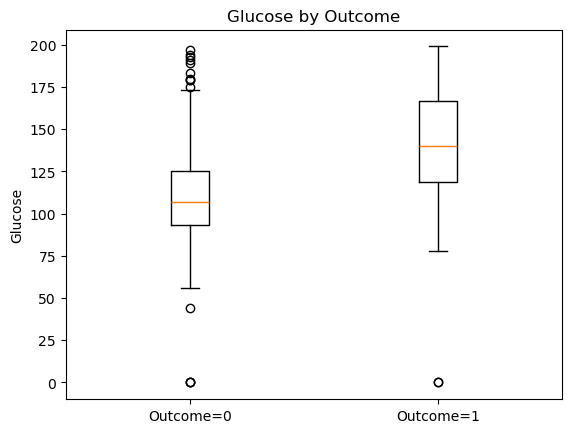

In [11]:
# TO DO: create two groups of Glucose values by Outcome
g0 = df[df['Outcome'] == 0]['Glucose']
g1 = df[df['Outcome'] == 1]['Glucose']

plt.figure()

# TO DO: boxplot comparing the two groups (hint: plt.boxplot)
# labels should be ["Outcome=0", "Outcome=1"]
plt.boxplot([g0, g1], labels=["Outcome=0", "Outcome=1"])

plt.title("Glucose by Outcome")
plt.ylabel("Glucose")
plt.show()

Interpretation: Compare medians and variability. Do the groups appear separated?

In [ ]:
The median glucose level for Outcome=1 is higher than for Outcome=0. 
The variability in the Outcome=1 group also appears larger. 
The two groups overlap somewhat, but Outcome=1 generally shows higher glucose values. 
This suggests that higher glucose levels are associated with Outcome=1.

### 3D. Scatter: Age vs BMI (by Outcome)

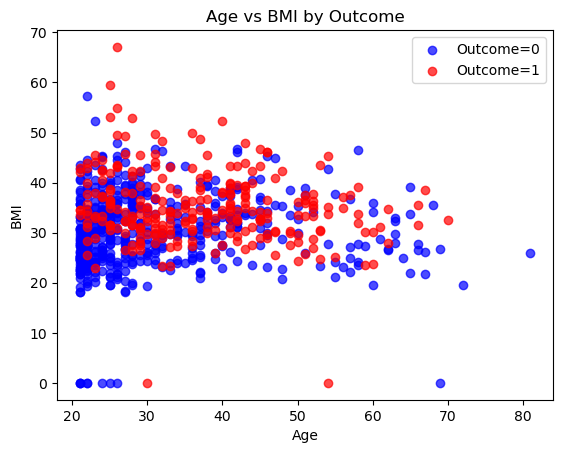

In [12]:
# TO DO: split dataset by Outcome
df0 = df[df['Outcome'] == 0]
df1 = df[df['Outcome'] == 1]

plt.figure()

# TO DO: scatter plots for the two groups (hint: plt.scatter)
# Use alpha=0.7 and include labels.
plt.scatter(df0['Age'], df0['BMI'], alpha=0.7, label='Outcome=0', color='blue')
plt.scatter(df1['Age'], df1['BMI'], alpha=0.7, label='Outcome=1', color='red')

plt.title("Age vs BMI by Outcome")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.legend()
plt.show()


Interpretation: Do you see clustering or separation between groups?

In [ ]:
The plot shows significant overlap, indicating that groups are not clearly separated by Age and BMI alone. 
However, a slight clustering of Outcome 1 (diabetic) is visible in the upper-right region, suggesting that higher BMI combined with older age increases the likelihood of a positive outcome. 
Most Outcome 0 cases cluster at lower BMI levels regardless of age.

## 4. Group Comparison Summary (Descriptive)

TO DO:
1) Compute group means for Glucose, BMI, Age by Outcome  
2) Compute mean differences (Outcome=1 minus Outcome=0)  


In [13]:
# TO DO: group means table (hint: groupby + mean)
summary_means = df.groupby('Outcome').mean()
summary_means


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [14]:
# TO DO: compute mean differences (Outcome=1 minus Outcome=0)
# hint: summary_means.loc[1] - summary_means.loc[0]
mean_diff = summary_means.loc[1] - summary_means.loc[0]
mean_diff


Pregnancies                  1.567672
Glucose                     31.277463
BloodPressure                2.640627
SkinThickness                2.500179
Insulin                     31.543821
BMI                          4.838337
DiabetesPedigreeFunction     0.120766
Age                          5.877164
dtype: float64

Interpretation (5–8 lines):
- Which variables show the biggest differences between Outcome groups?
- Which 1–2 variables look most promising as “associated with Outcome” (based on descriptive evidence)?
- Be cautious: do not claim causality.

In [ ]:
Glucose and Insulin show the biggest differences between the two Outcome groups. Age and BMI also show noticeable differences between the groups. 
This suggests that these variables may be related to diabetes status.Among them, Glucose appears to be the most promising variable because the average glucose level is much higher in the diabetes group. 
BMI and Age may also be associated with Outcome.However, these results only show statistical associations. They do not prove that these variables directly cause diabetes.

## 5. Sampling Simulation (Concept Preparation)

Goal: understand sampling variability of the sample mean.

TO DO:
1) Sample n = 30 observations (with replacement)  
2) Compute the sample mean of Glucose  
3) Repeat B = 1000 times  
4) Plot the distribution of sample means (matplotlib)  
5) Report the mean and standard deviation of the sampling distribution  


In [ ]:
# TO DO: set simulation parameters
B = 1000  # Number of bootstrap repetitions
n = 30    # Sample size per repetition

In [ ]:
means = []

for b in range(B):
    # TO DO: draw a bootstrap sample of size n (with replacement)
    sample = df.sample(n, replace=True)
    
    # TO DO: compute mean of Glucose in this sample
    m = sample['Glucose'].mean()
    
    means.append(m)

means = np.array(means)

In [ ]:
plt.figure()

# TO DO: histogram of simulated sample means (hint: plt.hist)
plt.hist(means, bins=30, color='gold', edgecolor='black', alpha=0.8)

plt.title("Sampling Distribution of Mean(Glucose), n=30")
plt.xlabel("Sample mean of Glucose")
plt.ylabel("Count")
plt.show()

In [ ]:
# TO DO: report center and spread of the sampling distribution
# hint: means.mean() and means.std(ddof=1)
center = means.mean()
spread = means.std(ddof=1)

print(f"Center (Mean of Sample Means): {center:.2f}")
print(f"Spread (Standard Error): {spread:.2f}")


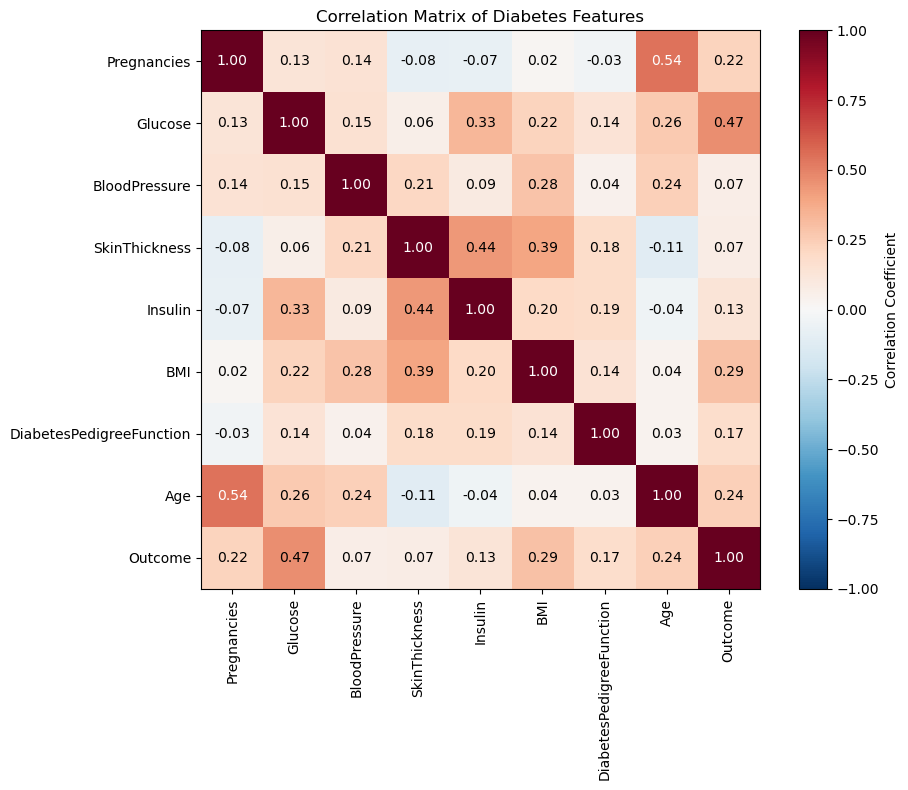

In [15]:
# TO DO: implement your extension here (Correlation Heatmap)
# 計算所有變數之間的相關係數
corr = df.corr()

plt.figure(figsize=(10, 8))

# 使用 imshow 繪製熱圖，顏色範圍設定在 -1 到 1
im = plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)

# 加入顏色條 (Colorbar)
plt.colorbar(im, label='Correlation Coefficient')

# 設定軸標籤
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# 在格子中填入數字，方便閱讀
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        color = "white" if abs(corr.iloc[i, j]) > 0.5 else "black"
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", 
                 ha="center", va="center", color=color)

plt.title("Correlation Matrix of Diabetes Features")
plt.tight_layout()
plt.show()


### 6C. Extension Interpretation (5–8 lines)
TO DO: Interpret what your extension shows and how it supports/changes your conclusions.

In [ ]:
The extension analysis shows that as the sample size increases from n=30 to n=100, the sampling distribution of Glucose becomes much narrower and more concentrated around the mean.
While the shape remains Normal and the center stays at the population mean, the variability (Standard Error) decreases significantly. 
This directly supports the Central Limit Theorem, proving that larger samples provide a more reliable and precise estimate of the true population parameters. 
This change reinforces my earlier conclusion that sampling variability is predictable and manageable with sufficient data. 
Consequently, increasing $n$ effectively reduces the likelihood of obtaining an extreme or unrepresentative sample mean.  

## 7. Week C Exhibition Reflection (After Rotations)

After you visit other groups during Week C, write at least **three** items:

1) One interesting analysis/visualization idea you saw  
2) One interpretation insight that was better than yours (what and why)  
3) One improvement you would apply to your own workflow next time  


Reflection notes:

1)

2)

3)
